In [9]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from data_loader import load_ceus_data
from filters import filter_both



In [ ]:
DATA_PATH = "../PALA/PALA_data_InVivoRatBrain/IQ"
# Examples:
#   Single file: "/home/user/scan.mat"
#   Folder:      "/home/user/data_folder"

N_COMPONENTS = 5  # ← ADJUST IF NEEDED

In [19]:
def process_single_file(mat_file: str, n_components: int = 5) -> dict:
    """Process a single .mat file and return structured data."""
    
    print(f"\nProcessing: {Path(mat_file).name}")
    print("-"*60)
    
    # Load
    data = load_ceus_data(mat_file)
    IQ_magnitude = data['IQ_magnitude']
    params = data['params']
    
    # Filter
    tissue, bubbles = filter_both(IQ_magnitude, n_components=n_components)
    
    # Build per-frame dictionary
    z, x, t = tissue.shape
    frames = {}
    for frame_idx in range(t):
        frames[frame_idx] = {
            'IQ_magnitude': IQ_magnitude[:, :, frame_idx],
            'tissue': tissue[:, :, frame_idx],
            'bubbles': bubbles[:, :, frame_idx]
        }
    
    return {
        'IQ_magnitude': IQ_magnitude,
        'tissue': tissue,
        'bubbles': bubbles,
        'params': params,
        'frames': frames,
        'filename': Path(mat_file).name
    }
    

In [20]:
def main_data():
    print("="*60)
    print("CEUS Data Processing")
    print("="*60)
    print(f"Input: {DATA_PATH}")
    print(f"SVD components: {N_COMPONENTS}")
    print()
    
    path = Path(DATA_PATH)
    
    # Check if path exists
    if not path.exists():
        print(f"ERROR: Path does not exist: {DATA_PATH}")
        print("Please edit DATA_PATH in this script (line 15)")
        return None
    
    # Single file
    if path.is_file() and path.suffix == '.mat':
        print("Mode: Single file")
        data = process_single_file(str(path), n_components=N_COMPONENTS)
        
        print("\n" + "="*60)
        print("SUCCESS!")
        print("="*60)
        print(f"Shape: {data['tissue'].shape}")
        print(f"Frames: {data['tissue'].shape[2]}")
        print()
        print("  data['tissue']       - full tissue array [z,x,t]")
        print("  data['bubbles']      - full bubbles array [z,x,t]")
        print("  data['frames'][10]   - frame 10")
        print("  data['params']       - acquisition parameters")
        
        return data
    
    # Folder with multiple files
    elif path.is_dir():
        print("Mode: Folder (batch processing)")
        
        mat_files = list(path.glob('*.mat'))
        if len(mat_files) == 0:
            print(f"ERROR: No .mat files found in {DATA_PATH}")
            return {}
        
        print(f"Found {len(mat_files)} .mat files")
        print()
        
        all_data = {}
        for i, mat_file in enumerate(mat_files, 1):
            print(f"[{i}/{len(mat_files)}]", end=" ")
            
            try:
                data = process_single_file(str(mat_file), n_components=N_COMPONENTS)
                all_data[mat_file.stem] = data
                print(f"  ✓ Success: {data['tissue'].shape}")
            except Exception as e:
                print(f"  ✗ Error: {e}")
                continue
        
        print("\n" + "="*60)
        print("COMPLETE!")
        print("="*60)
        print(f"Successfully processed: {len(all_data)}/{len(mat_files)} files")
        print()
        print("Access your data:")
        print("  all_data['filename']['tissue']   - tissue for that file")
        print("  all_data['filename']['bubbles']  - bubbles for that file")
        print("  all_data['filename']['frames'][i] - specific frame")
        
        if len(all_data) > 0:
            first_key = list(all_data.keys())[0]
            print()
            print("Example:")
            print(f"  data = all_data['{first_key}']")
            print(f"  tissue = data['tissue']  # shape: {all_data[first_key]['tissue'].shape}")
        
        return all_data
    
    else:
        print(f"ERROR: Path must be a .mat file or a folder")
        print(f"Got: {DATA_PATH}")
        return None

In [21]:
data = main_data()

CEUS Data Processing
Input: ../PALA/PALA_data_InVivoRatBrain/IQ
SVD components: 50

Mode: Folder (batch processing)
Found 120 .mat files

[1/120] 
Processing: PALA_InVivoRatBrain_001.mat
------------------------------------------------------------
Loading ..\PALA\PALA_data_InVivoRatBrain\IQ\PALA_InVivoRatBrain_001.mat...
  Shape: (78, 118, 800)
  Frequency: 15.0 MHz
  Frame rate: 1000.0 Hz
Filtering tissue and microbubbles (SVD with 50 components)...
  Computing SVD...
  Tissue: 99.5% energy
  Bubbles: 0.5% energy
  ✓ Success: (78, 118, 800)
[2/120] 
Processing: PALA_InVivoRatBrain_002.mat
------------------------------------------------------------
Loading ..\PALA\PALA_data_InVivoRatBrain\IQ\PALA_InVivoRatBrain_002.mat...
  Shape: (78, 118, 800)
  Frequency: 15.0 MHz
  Frame rate: 1000.0 Hz
Filtering tissue and microbubbles (SVD with 50 components)...
  Computing SVD...
  Tissue: 99.6% energy
  Bubbles: 0.4% energy
  ✓ Success: (78, 118, 800)
[3/120] 
Processing: PALA_InVivoRatBrain_0

In [22]:
import os
print("Current directory:", os.getcwd())
print("\nFiles here:", os.listdir('.'))

Current directory: c:\ultrasoundproject\us_model

Files here: ['data_loader.py', 'filters.py', 'preprocecing_ex_notebook.ipynb', 'preprocessing_example.py', 'solver.py', '__pycache__']


Available files:
['PALA_InVivoRatBrain_001', 'PALA_InVivoRatBrain_002', 'PALA_InVivoRatBrain_003', 'PALA_InVivoRatBrain_004', 'PALA_InVivoRatBrain_005', 'PALA_InVivoRatBrain_006', 'PALA_InVivoRatBrain_007', 'PALA_InVivoRatBrain_008', 'PALA_InVivoRatBrain_009', 'PALA_InVivoRatBrain_010', 'PALA_InVivoRatBrain_011', 'PALA_InVivoRatBrain_012', 'PALA_InVivoRatBrain_013', 'PALA_InVivoRatBrain_014', 'PALA_InVivoRatBrain_015', 'PALA_InVivoRatBrain_016', 'PALA_InVivoRatBrain_017', 'PALA_InVivoRatBrain_018', 'PALA_InVivoRatBrain_019', 'PALA_InVivoRatBrain_020', 'PALA_InVivoRatBrain_021', 'PALA_InVivoRatBrain_022', 'PALA_InVivoRatBrain_023', 'PALA_InVivoRatBrain_024', 'PALA_InVivoRatBrain_025', 'PALA_InVivoRatBrain_026', 'PALA_InVivoRatBrain_027', 'PALA_InVivoRatBrain_028', 'PALA_InVivoRatBrain_029', 'PALA_InVivoRatBrain_030', 'PALA_InVivoRatBrain_031', 'PALA_InVivoRatBrain_032', 'PALA_InVivoRatBrain_033', 'PALA_InVivoRatBrain_034', 'PALA_InVivoRatBrain_035', 'PALA_InVivoRatBrain_036', 'PALA_InVi

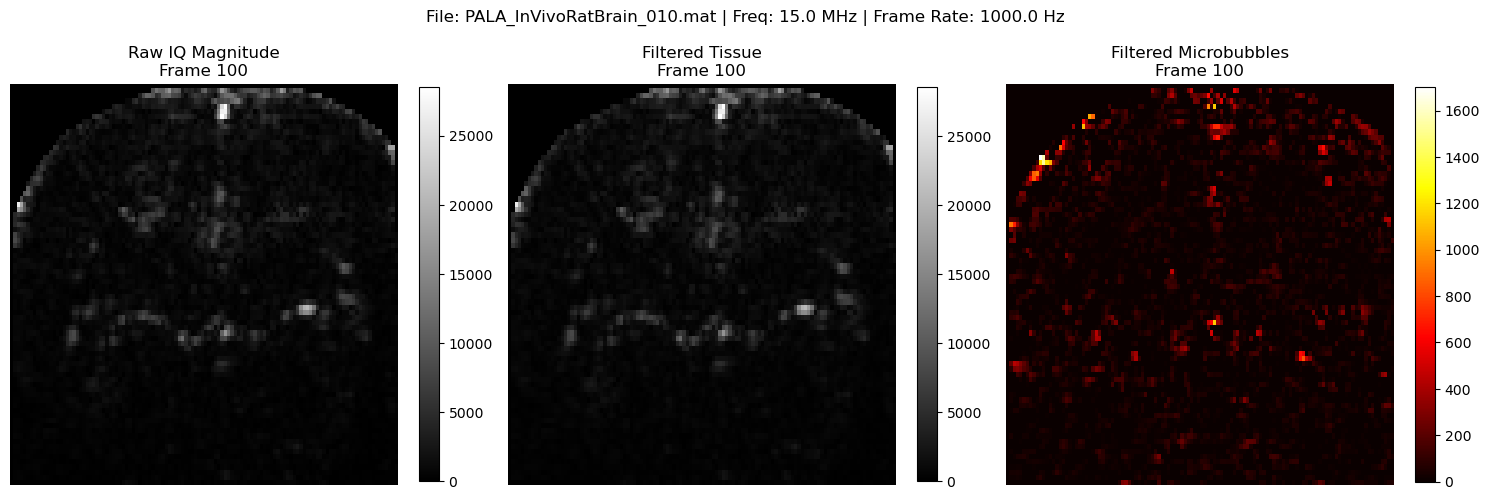


Frame 100 Statistics:
  Raw range:     [0.00, 28524.13]
  Tissue range:  [-42.06, 28581.24]
  Bubbles range: [0.00, 1702.23]


: 

In [ ]:

print("Available files:")
print(list(data.keys()))
# If single file, data is directly accessible:
# visualization_data = data

# If folder (multiple files), choose which file:
FILE_NAME = 'PALA_InVivoRatBrain_010'  # ← Change to your filename (without .mat)
visualization_data = data[FILE_NAME]  # Comment this line if single file

FRAME_NUMBER = 100  # ← Choose which frame to visualize (0 to num_frames-1)



def visualize_frame(data_struct, frame_idx):
    """
    Visualize raw and filtered images for a specific frame.
    """
    # Get the frame
    frame = data_struct['frames'][frame_idx]
    
    # Create figure
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Raw IQ magnitude
    im0 = axes[0].imshow(frame['IQ_magnitude'], aspect='auto', cmap='gray')
    axes[0].set_title(f'Raw IQ Magnitude\nFrame {frame_idx}')
    axes[0].axis('off')
    plt.colorbar(im0, ax=axes[0], fraction=0.046)
    
    # Filtered Tissue
    im1 = axes[1].imshow(frame['tissue'], aspect='auto', cmap='gray')
    axes[1].set_title(f'Filtered Tissue\nFrame {frame_idx}')
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1], fraction=0.046)
    
    # Filtered Bubbles
    im2 = axes[2].imshow(frame['bubbles'], aspect='auto', cmap='hot')
    axes[2].set_title(f'Filtered Microbubbles\nFrame {frame_idx}')
    axes[2].axis('off')
    plt.colorbar(im2, ax=axes[2], fraction=0.046)
    
    # Add info
    params = data_struct['params']
    fig.suptitle(f"File: {data_struct['filename']} | "
                 f"Freq: {params['TwFreq']} MHz | "
                 f"Frame Rate: {params['FrameRateUF']} Hz",
                 fontsize=12, y=0.98)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\nFrame {frame_idx} Statistics:")
    print(f"  Raw range:     [{frame['IQ_magnitude'].min():.2f}, {frame['IQ_magnitude'].max():.2f}]")
    print(f"  Tissue range:  [{frame['tissue'].min():.2f}, {frame['tissue'].max():.2f}]")
    print(f"  Bubbles range: [{frame['bubbles'].min():.2f}, {frame['bubbles'].max():.2f}]")


# Visualize
visualize_frame(visualization_data, FRAME_NUMBER)


In [ ]:
# Show temporal maximum to see overall vessel structure

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Tissue temporal max
axes[0].imshow(np.max(visualization_data['tissue'], axis=2), aspect='auto', cmap='gray')
axes[0].set_title('Tissue (Temporal Maximum)')
axes[0].axis('off')

# Bubbles temporal max
axes[1].imshow(np.max(visualization_data['bubbles'], axis=2), aspect='auto', cmap='hot')
axes[1].set_title('Microbubbles (Temporal Maximum)')
axes[1].axis('off')

plt.suptitle(f"File: {visualization_data['filename']}", fontsize=12)
plt.tight_layout()
plt.show()